# PROYECTO FINAL

# Análisis Exploratorio y Estadístico de las Ventas de una Tienda de Tecnología

**Estudiante:** Yulianis Saray Rojas Estrada

**Universidad:** Universidad EAN

**Asignatura:** Dataxperience

**Profesor:** (Camila Silva Gomez)

**Fecha:** Septiembre 2026


# Introducción

La analítica de datos permite transformar grandes cantidades de información en conocimiento útil para apoyar la toma de decisiones.

En este proyecto se analizará un conjunto de datos correspondiente a las ventas de una tienda de tecnología. A través de técnicas de exploración, limpieza y análisis estadístico se identificarán patrones, posibles problemas en los datos y características importantes de las ventas.

El desarrollo del proyecto se realizará utilizando Python en Google Colab, empleando librerías como Pandas, NumPy y Matplotlib para procesar y visualizar la información.

# Objetivo General

Analizar un conjunto de datos de ventas mediante técnicas de preparación, limpieza y análisis estadístico utilizando Python y Google Colab.

# Objetivos Específicos

- Seleccionar un conjunto de datos adecuado para el análisis.
- Explorar las características principales del dataset.
- Detectar errores, valores nulos y registros duplicados.
- Limpiar y transformar los datos para mejorar su calidad.
- Calcular medidas estadísticas descriptivas.
- Representar la información mediante gráficos.
- Interpretar los resultados obtenidos.

## Selección del conjunto de datos

Para este proyecto se utilizó un conjunto de datos simulado que representa las ventas de una tienda de tecnología. El dataset fue diseñado con fines académicos e incluye información sobre productos, categorías, precios, cantidades vendidas, descuentos, métodos de pago, ciudades y el valor total de cada venta.

Este conjunto de datos permite aplicar técnicas de exploración, limpieza, transformación y análisis estadístico, simulando una situación similar a la que puede presentarse en una empresa del sector tecnológico.

# MÓDULO 1

## Selección del conjunto de datos

## Justificación

Se eligió un conjunto de datos relacionado con las ventas de una tienda de tecnología porque representa un escenario común en el ámbito empresarial. Este tipo de información permite aplicar técnicas de análisis de datos para identificar tendencias, comprender el comportamiento de las ventas y apoyar la toma de decisiones.

Además, este conjunto de datos se relaciona con la analítica de datos, ya que permite poner en práctica procesos de exploración, limpieza y análisis estadístico utilizando herramientas como Python y Google Colab.


In [86]:
# ==========================================
# LIBRERÍAS
# ==========================================

import pandas as pd
import numpy as np
import random

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime, timedelta

# Configuración de gráficos
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,5)

# Semilla para que siempre genere los mismos datos
random.seed(42)
np.random.seed(42)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [87]:
# Productos disponibles

productos = [
    "Laptop",
    "Mouse",
    "Teclado",
    "Monitor",
    "Tablet",
    "Celular",
    "Audífonos",
    "Impresora"
]

categorias = {
    "Laptop":"Computadores",
    "Mouse":"Accesorios",
    "Teclado":"Accesorios",
    "Monitor":"Pantallas",
    "Tablet":"Dispositivos",
    "Celular":"Dispositivos",
    "Audífonos":"Audio",
    "Impresora":"Oficina"
}

metodos_pago = [
    "Efectivo",
    "Tarjeta",
    "Transferencia"
]

ciudades = [
    "Bogotá",
    "Medellín",
    "Cali",
    "Barranquilla",
    "Bucaramanga"
]

In [88]:
# Crear 200 registros

datos = []

fecha_inicio = datetime(2026,1,1)

for i in range(200):

    producto = random.choice(productos)

    precio = random.randint(50000,4000000)

    cantidad = random.randint(1,8)

    descuento = random.choice([0,5,10,15])

    fecha = fecha_inicio + timedelta(days=random.randint(0,250))

    ciudad = random.choice(ciudades)

    pago = random.choice(metodos_pago)

    subtotal = precio * cantidad

    total = subtotal - (subtotal * descuento / 100)

    datos.append([
        fecha,
        producto,
        categorias[producto],
        precio,
        cantidad,
        descuento,
        pago,
        ciudad,
        round(total,2)
    ])

df = pd.DataFrame(
    datos,
    columns=[
        "Fecha",
        "Producto",
        "Categoria",
        "Precio",
        "Cantidad",
        "Descuento",
        "MetodoPago",
        "Ciudad",
        "Total"
    ]
)

df.head()

,Fecha,Producto,Categoria,Precio,Cantidad,Descuento,MetodoPago,Ciudad,Total
0,2026-02-27,Mouse,Accesorios,154902,5,5,Transferencia,Medellín,735784.5
1,2026-01-09,Mouse,Accesorios,2888283,2,15,Efectivo,Bogotá,4910081.1
2,2026-07-03,Monitor,Pantallas,1025850,1,5,Tarjeta,Bucaramanga,974557.5
3,2026-07-14,Monitor,Pantallas,1934119,5,0,Transferencia,Medellín,9670595.0
4,2026-02-25,Audífonos,Audio,1477114,5,5,Efectivo,Cali,7016291.5


### Creación del conjunto de datos

Se generó un conjunto de datos con 200 registros que representan ventas de una tienda de tecnología. Las variables incluidas permiten realizar un análisis estadístico y explorar el comportamiento de las ventas.

En las siguientes etapas se incorporarán algunos errores de forma intencional (como valores nulos, duplicados y diferencias en la escritura) para demostrar el proceso de limpieza de datos.

In [89]:
# ===========================
# CREAR ERRORES INTENCIONALMENTE
# ===========================

# Copiamos el dataframe original
df_original = df.copy()

# 1. Crear duplicados
duplicados = df.sample(5, random_state=42)
df = pd.concat([df, duplicados], ignore_index=True)

# 2. Valores nulos
df.loc[8, "Precio"] = np.nan
df.loc[25, "Cantidad"] = np.nan
df.loc[40, "MetodoPago"] = np.nan

# 3. Errores de escritura
df.loc[15, "Producto"] = "mouse"
df.loc[35, "Producto"] = " LAPTOP "
df.loc[60, "Producto"] = "tablet"

print("Errores agregados correctamente.")

Errores agregados correctamente.


## Exploración de los datos

Antes de realizar el análisis estadístico, es necesario conocer la estructura del conjunto de datos e identificar posibles problemas que puedan afectar los resultados.

In [90]:
# Primeras filas

df.head()

# Últimas filas

df.tail()

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Filas: 205
Columnas: 9


El conjunto de datos contiene información de ventas de una tienda de tecnología. Después de agregar algunos errores para el proceso de limpieza, el número de registros aumentó debido a los duplicados creados intencionalmente.

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Fecha       205 non-null    datetime64[ns]
 1   Producto    205 non-null    object        
 2   Categoria   205 non-null    object        
 3   Precio      204 non-null    float64       
 4   Cantidad    204 non-null    float64       
 5   Descuento   205 non-null    int64         
 6   MetodoPago  204 non-null    object        
 7   Ciudad      205 non-null    object        
 8   Total       205 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 14.5+ KB


La función `info()` permite conocer el tipo de dato de cada columna y verificar si existen valores nulos.

df.describe()

Las estadísticas descriptivas muestran información importante sobre las variables numéricas, como el promedio, el valor mínimo, el máximo y la desviación estándar.

In [92]:
df.isnull().sum()
print("Duplicados:", df.duplicated().sum())
df["Producto"].unique()
variables = pd.DataFrame({

    "Variable":df.columns,

    "Tipo":df.dtypes

})

variables

Duplicados: 4


,Variable,Tipo
Fecha,Fecha,datetime64[ns]
Producto,Producto,object
Categoria,Categoria,object
Precio,Precio,float64
Cantidad,Cantidad,float64
Descuento,Descuento,int64
MetodoPago,MetodoPago,object
Ciudad,Ciudad,object
Total,Total,float64


### Tipos de variables

- Fecha → Fecha

- Producto → Categórica

- Categoria → Categórica

- Precio → Numérica

- Cantidad → Numérica

- Descuento → Numérica

- MetodoPago → Categórica

- Ciudad → Categórica

- Total → Numérica

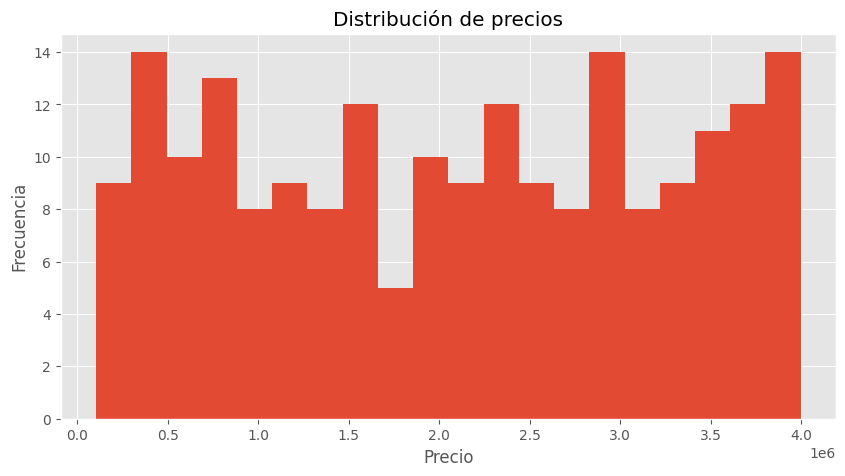

In [93]:
df["Producto"].value_counts()
df["Ciudad"].value_counts()
df["MetodoPago"].value_counts(dropna=False)
plt.figure(figsize=(10,5))

plt.hist(df["Precio"].dropna(), bins=20)

plt.title("Distribución de precios")

plt.xlabel("Precio")

plt.ylabel("Frecuencia")

plt.show()


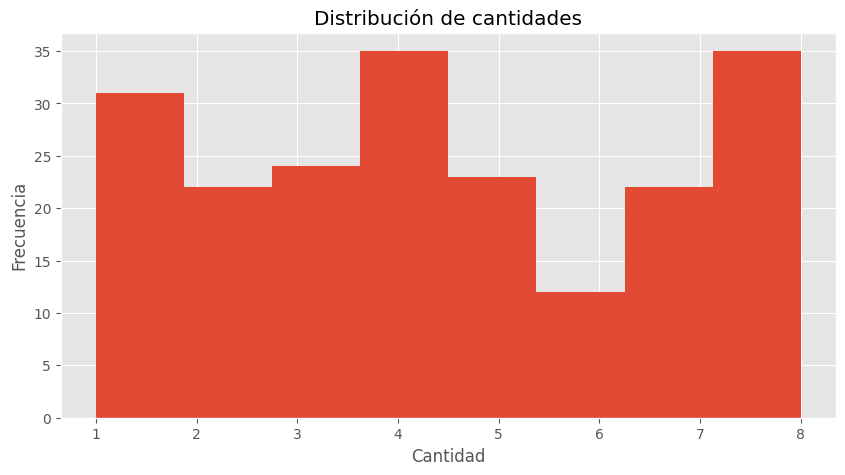

In [94]:
plt.figure(figsize=(10,5))

plt.hist(df["Cantidad"].dropna(), bins=8)

plt.title("Distribución de cantidades")

plt.xlabel("Cantidad")

plt.ylabel("Frecuencia")

plt.show()

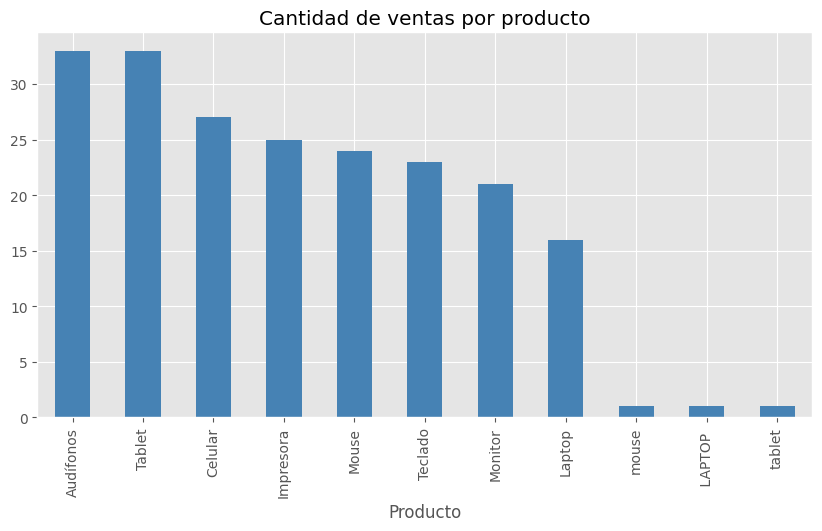

In [95]:
df["Producto"].value_counts().plot(

kind="bar",

color="steelblue"

)

plt.title("Cantidad de ventas por producto")

plt.show()

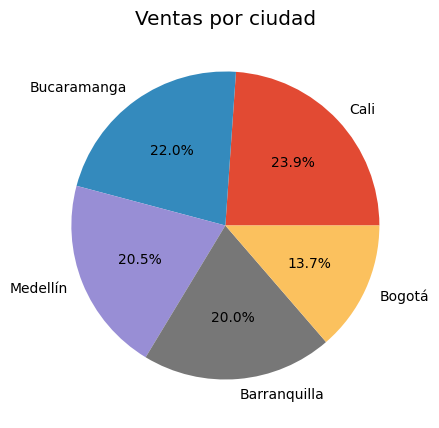

In [96]:
df["Ciudad"].value_counts().plot(

kind="pie",

autopct="%1.1f%%"

)

plt.ylabel("")

plt.title("Ventas por ciudad")

plt.show()


## Problemas detectados

Durante la exploración del conjunto de datos se encontraron los siguientes problemas:

- Se identificaron valores nulos en algunas columnas.

- Existen registros duplicados.

- Algunos nombres de productos presentan diferencias en la escritura.

- Se detectaron espacios adicionales en algunos registros.

Estos problemas deben corregirse antes de realizar el análisis estadístico.

In [97]:
df.head(20)

,Fecha,Producto,Categoria,Precio,Cantidad,Descuento,MetodoPago,Ciudad,Total
0,2026-02-27,Mouse,Accesorios,154902.0,5.0,5,Transferencia,Medellín,735784.50
1,2026-01-09,Mouse,Accesorios,2888283.0,2.0,15,Efectivo,Bogotá,4910081.10
2,2026-07-03,Monitor,Pantallas,1025850.0,1.0,5,Tarjeta,Bucaramanga,974557.50
3,2026-07-14,Monitor,Pantallas,1934119.0,5.0,0,Transferencia,Medellín,9670595.00
4,2026-02-25,Audífonos,Audio,1477114.0,5.0,5,Efectivo,Cali,7016291.50
5,2026-08-05,Mouse,Accesorios,1643530.0,2.0,10,Transferencia,Cali,2958354.00
6,2026-05-18,Tablet,Dispositivos,3435341.0,1.0,15,Tarjeta,Bogotá,2920039.85
7,2026-05-28,Mouse,Accesorios,2365426.0,5.0,10,Transferencia,Medellín,10644417.00
8,2026-01-21,Mouse,Accesorios,NaN,4.0,10,Efectivo,Medellín,871923.60
9,2026-02-11,Audífonos,Audio,1215905.0,8.0,10,Tarjeta,Cali,8754516.00


# Limpieza y Transformación de Datos

Después de explorar el conjunto de datos se identificaron algunos problemas de calidad, como valores nulos, registros duplicados y diferencias en la escritura de algunos productos.

En esta etapa se realizarán las correcciones necesarias para garantizar que los datos sean consistentes y adecuados para el análisis estadístico.

In [98]:
print("="*50)
print("VALORES NULOS")
print("="*50)

print(df.isnull().sum())

print("\n")

print("="*50)
print("REGISTROS DUPLICADOS")
print("="*50)

print(df.duplicated().sum())

print("\n")

print("="*50)
print("NOMBRES DE PRODUCTOS")
print("="*50)

print(df["Producto"].unique())

VALORES NULOS
Fecha         0
Producto      0
Categoria     0
Precio        1
Cantidad      1
Descuento     0
MetodoPago    1
Ciudad        0
Total         0
dtype: int64


REGISTROS DUPLICADOS
4


NOMBRES DE PRODUCTOS
['Mouse' 'Monitor' 'Audífonos' 'Tablet' 'Celular' 'mouse' 'Laptop'
 'Teclado' 'Impresora' ' LAPTOP ' 'tablet']


### Observaciones

Antes de comenzar la limpieza se observaron tres problemas principales:

- Existían valores nulos.
- Había registros duplicados.
- Algunos nombres de productos tenían espacios adicionales o estaban escritos de manera diferente.

In [99]:
df["Producto"] = df["Producto"].str.strip()

print(df["Producto"].unique())

df["Producto"] = df["Producto"].str.title()

print(df["Producto"].unique())

['Mouse' 'Monitor' 'Audífonos' 'Tablet' 'Celular' 'mouse' 'Laptop'
 'Teclado' 'Impresora' 'LAPTOP' 'tablet']
['Mouse' 'Monitor' 'Audífonos' 'Tablet' 'Celular' 'Laptop' 'Teclado'
 'Impresora']


In [100]:
print("Antes:", df.shape)
df = df.drop_duplicates()
print("Después:", df.shape)

Antes: (205, 9)
Después: (201, 9)


Se eliminaron los registros duplicados para evitar que una misma venta fuera contabilizada más de una vez durante el análisis.

In [101]:
media_precio = df["Precio"].mean()

df["Precio"] = df["Precio"].fillna(media_precio)

print(df["Precio"].isnull().sum())

0


In [102]:
mediana = df["Cantidad"].median()

df["Cantidad"] = df["Cantidad"].fillna(mediana)
print(df["Cantidad"].isnull().sum())

0


In [103]:
moda = df["MetodoPago"].mode()[0]

df["MetodoPago"] = df["MetodoPago"].fillna(moda)

print(df["MetodoPago"].isnull().sum())

0


In [104]:
df.isnull().sum()

,0
Fecha,0
Producto,0
Categoria,0
Precio,0
Cantidad,0
Descuento,0
MetodoPago,0
Ciudad,0
Total,0


In [105]:
print(df.duplicated().sum())

0


In [106]:
df.head(15)

df.to_csv("dataset_limpio.csv", index=False)

print("Dataset guardado correctamente.")

Dataset guardado correctamente.


# Resumen de la limpieza

Durante la preparación de los datos se realizaron las siguientes acciones:

- Se eliminaron espacios en los nombres de los productos.
- Se unificó la escritura de los productos utilizando formato de título.
- Se eliminaron registros duplicados.
- Se reemplazaron los valores nulos del precio utilizando la media.
- Se reemplazaron los valores nulos de la cantidad utilizando la mediana.
- Se reemplazaron los valores nulos del método de pago utilizando la moda.

Después de la limpieza, el conjunto de datos quedó listo para realizar el análisis estadístico.

# Conclusión del Módulo 1

Durante esta etapa se seleccionó y preparó el conjunto de datos para su análisis. Se identificaron valores nulos, registros duplicados e inconsistencias en algunos registros, los cuales fueron corregidos mediante técnicas de limpieza y transformación.

Como resultado, se obtuvo un conjunto de datos organizado y listo para realizar el análisis estadístico del Módulo 2.

# 📊 MÓDULO 2 - Análisis Estadístico

## Objetivo

Aplicar medidas estadísticas descriptivas para comprender el comportamiento del conjunto de datos y obtener información útil para la toma de decisiones.

## Introducción

Una vez finalizada la limpieza del conjunto de datos, se procede a realizar un análisis estadístico para comprender el comportamiento de las ventas. Se calcularán medidas de tendencia central y de dispersión, además de representar los datos mediante gráficos que permitan identificar patrones, diferencias y posibles oportunidades de mejora.

In [107]:
df.describe()

,Fecha,Precio,Cantidad,Descuento,Total
count,201,2.010000e+02,201.000000,201.000000,2.010000e+02
mean,2026-05-10 15:02:41.194029824,2.088250e+06,4.457711,7.661692,8.270469e+06
min,2026-01-01 00:00:00,1.030660e+05,1.000000,0.000000,2.916486e+05
25%,2026-03-04 00:00:00,1.025850e+06,2.000000,0.000000,2.901495e+06
50%,2026-05-18 00:00:00,2.099360e+06,4.000000,10.000000,6.415323e+06
75%,2026-07-21 00:00:00,3.121739e+06,7.000000,15.000000,1.219031e+07
max,2026-09-07 00:00:00,3.997106e+06,8.000000,15.000000,3.197685e+07
std,NaN,1.174926e+06,2.399886,5.788348,6.825380e+06


### Interpretación

La tabla anterior presenta un resumen de las principales variables numéricas del conjunto de datos.

A partir de esta información es posible observar el comportamiento general de los precios, las cantidades vendidas, los descuentos y el valor total de las ventas.

Estos resultados sirven como base para realizar un análisis más detallado mediante medidas estadísticas descriptivas.

# Medidas de Tendencia Central

In [108]:
print("MEDIA")

print("Precio:",df["Precio"].mean())

print("Cantidad:",df["Cantidad"].mean())

print("Total:",df["Total"].mean())

MEDIA
Precio: 2088249.62
Cantidad: 4.45771144278607
Total: 8270469.354726368


### Interpretación de la media

La media representa el promedio de los valores registrados.

Permite conocer el comportamiento promedio de las ventas y facilita la comparación entre diferentes variables del conjunto de datos.

In [109]:
print("MEDIANA")

print("Precio:",df["Precio"].median())

print("Cantidad:",df["Cantidad"].median())

print("Total:",df["Total"].median())

MEDIANA
Precio: 2099360.0
Cantidad: 4.0
Total: 6415323.4


### Interpretación de la mediana

La mediana corresponde al valor central del conjunto de datos.

Esta medida resulta especialmente útil cuando existen valores muy altos o muy bajos, ya que no se ve tan afectada por ellos como la media.

In [110]:
print("MODA")

print(df["Producto"].mode())

print(df["MetodoPago"].mode())

print(df["Ciudad"].mode())

MODA
0    Audífonos
1       Tablet
Name: Producto, dtype: object
0    Efectivo
Name: MetodoPago, dtype: object
0    Cali
Name: Ciudad, dtype: object


### Interpretación de la moda

La moda identifica el valor que aparece con mayor frecuencia.

Gracias a esta medida es posible reconocer cuáles son los productos, ciudades o métodos de pago más utilizados por los clientes.

# Medidas de Dispersión

In [111]:
print("Rango Precio")

print(df["Precio"].max()-df["Precio"].min())

print()

print("Rango Cantidad")

print(df["Cantidad"].max()-df["Cantidad"].min())

print()

print("Rango Total")

print(df["Total"].max()-df["Total"].min())

print("Varianza Precio")

print(df["Precio"].var())

print()

print("Varianza Cantidad")

print(df["Cantidad"].var())

print()

print("Varianza Total")

print(df["Total"].var())

Rango Precio
3894040.0

Rango Cantidad
7.0

Rango Total
31685199.4
Varianza Precio
1380452109676.9949

Varianza Cantidad
5.759452736318407

Varianza Total
46585818807386.25


In [112]:
print("Desviación Estándar Precio")

print(df["Precio"].std())

print()

print("Desviación Estándar Cantidad")

print(df["Cantidad"].std())

print()

print("Desviación Estándar Total")

print(df["Total"].std())

Desviación Estándar Precio
1174926.4273464084

Desviación Estándar Cantidad
2.3998859840247424

Desviación Estándar Total
6825380.488103667


### Interpretación de las medidas de dispersión

Las medidas de dispersión permiten conocer qué tan separados se encuentran los datos respecto al promedio.

Un rango amplio indica una gran diferencia entre el valor mínimo y máximo.

La varianza y la desviación estándar muestran el nivel de variabilidad presente en las ventas.

# Comparación entre Variables

In [113]:
correlacion = df[["Precio","Cantidad","Descuento","Total"]].corr()

correlacion

,Precio,Cantidad,Descuento,Total
Precio,1.000000,-0.117968,-0.083278,0.622726
Cantidad,-0.117968,1.000000,0.109825,0.602448
Descuento,-0.083278,0.109825,1.000000,-0.089775
Total,0.622726,0.602448,-0.089775,1.000000


### Interpretación

La matriz de correlación permite identificar si existe relación entre las variables numéricas.

Valores cercanos a 1 indican una relación positiva fuerte, mientras que valores cercanos a -1 representan una relación negativa. Valores próximos a 0 indican poca relación.

# 📈 Visualización de los Datos

Los gráficos permiten comprender de forma más sencilla el comportamiento de las variables y facilitan la identificación de patrones, tendencias y posibles anomalías en el conjunto de datos.

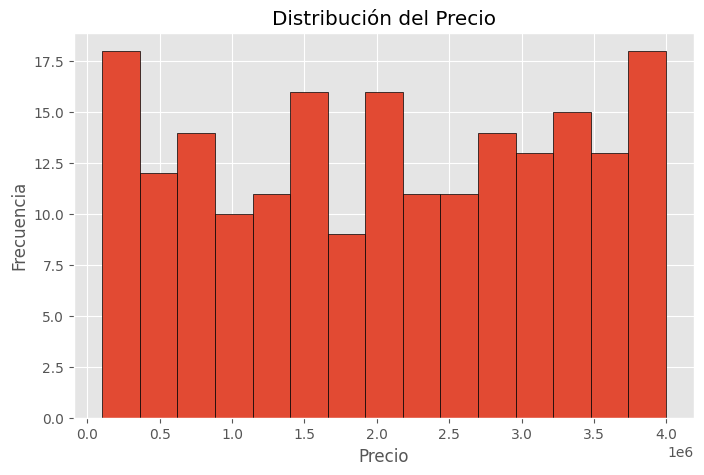

In [114]:
plt.figure(figsize=(8,5))

plt.hist(df["Precio"], bins=15, edgecolor="black")

plt.title("Distribución del Precio")

plt.xlabel("Precio")

plt.ylabel("Frecuencia")

plt.show()

### Interpretación

El histograma muestra cómo se distribuyen los precios de los productos vendidos. Permite identificar si la mayoría de las ventas corresponden a productos económicos o de mayor valor.

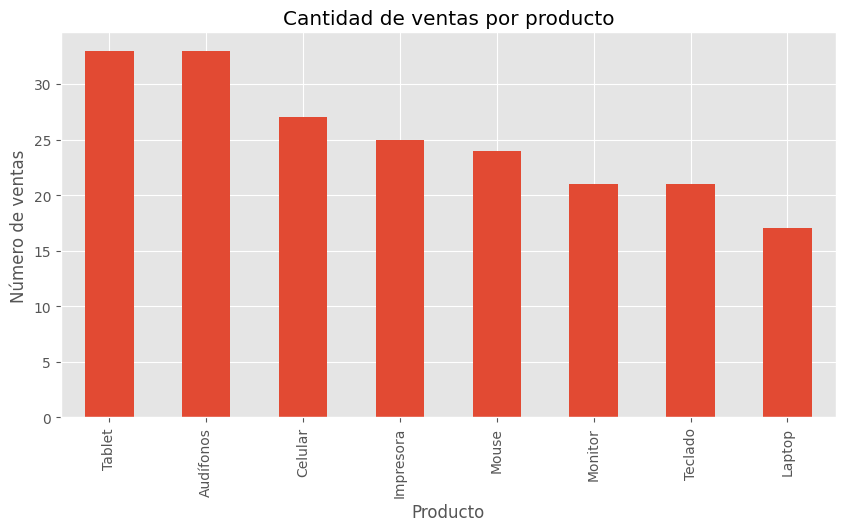

In [115]:
plt.figure(figsize=(10,5))

df["Producto"].value_counts().plot(kind="bar")

plt.title("Cantidad de ventas por producto")

plt.xlabel("Producto")

plt.ylabel("Número de ventas")

plt.show()

### Interpretación

Este gráfico permite identificar cuáles son los productos con mayor número de ventas y cuáles tienen menor participación dentro del conjunto de datos.

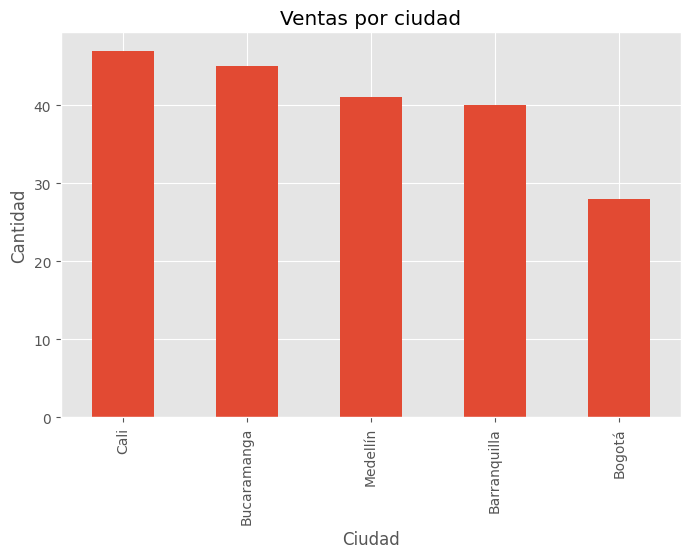

In [116]:
plt.figure(figsize=(8,5))

df["Ciudad"].value_counts().plot(kind="bar")

plt.title("Ventas por ciudad")

plt.xlabel("Ciudad")

plt.ylabel("Cantidad")

plt.show()

### Interpretación

Se observa la distribución de las ventas entre las diferentes ciudades. Esta información puede servir para identificar los mercados con mayor actividad comercial.

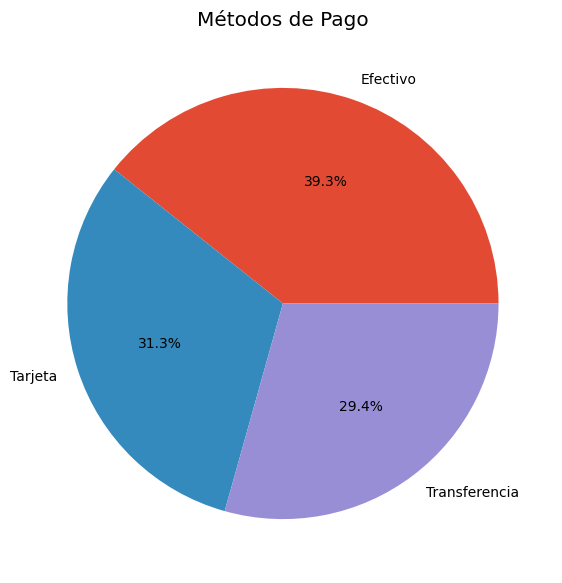

In [117]:
plt.figure(figsize=(7,7))

df["MetodoPago"].value_counts().plot(

kind="pie",

autopct="%1.1f%%"

)

plt.ylabel("")

plt.title("Métodos de Pago")

plt.show()

### Interpretación

El gráfico circular muestra la proporción de utilización de cada método de pago por parte de los clientes.

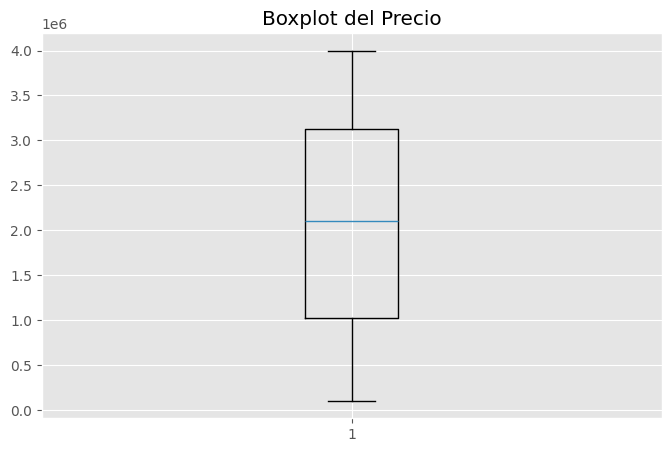

In [118]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Precio"])

plt.title("Boxplot del Precio")

plt.show()

### Interpretación

El boxplot permite identificar valores atípicos (outliers), además de mostrar la mediana y la dispersión de los precios.

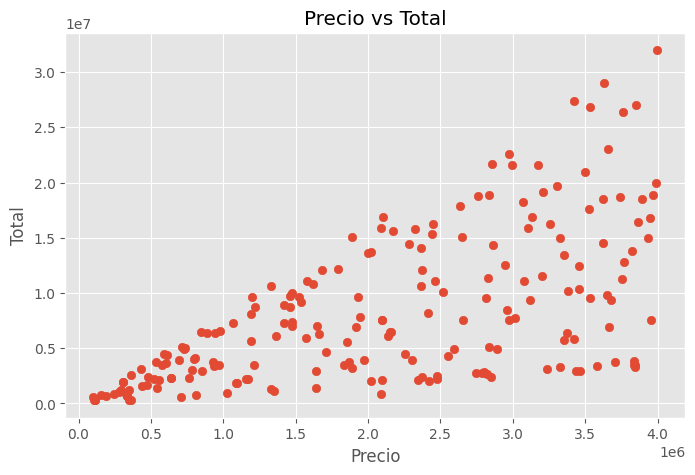

In [119]:
plt.figure(figsize=(8,5))

plt.scatter(df["Precio"],df["Total"])

plt.title("Precio vs Total")

plt.xlabel("Precio")

plt.ylabel("Total")

plt.show()

### Interpretación

El gráfico de dispersión permite observar si existe una relación entre el precio del producto y el valor total de la venta.

# Identificación de Valores Atípicos (Outliers)

In [120]:
Q1 = df["Precio"].quantile(0.25)

Q3 = df["Precio"].quantile(0.75)

IQR = Q3-Q1

limite_inferior = Q1-(1.5*IQR)

limite_superior = Q3+(1.5*IQR)

outliers = df[(df["Precio"]<limite_inferior) | (df["Precio"]>limite_superior)]

print("Cantidad de outliers:",len(outliers))

outliers.head()

Cantidad de outliers: 0


,Fecha,Producto,Categoria,Precio,Cantidad,Descuento,MetodoPago,Ciudad,Total


### Interpretación

Los valores atípicos corresponden a registros cuyos precios son significativamente diferentes respecto al resto de los datos.

Estos valores pueden representar ventas excepcionales o posibles errores en el registro de la información.

# Hipótesis del Análisis

A partir de la información analizada se plantean las siguientes hipótesis:

- Los productos con mayor precio generan un mayor valor total de venta.
- Algunos métodos de pago son utilizados con mayor frecuencia por los clientes.
- Existen ciudades que concentran un mayor volumen de ventas.
- Los descuentos influyen en el valor final de las transacciones.

# Historia del análisis

Imaginemos que esta información pertenece a una tienda de tecnología que desea conocer el comportamiento de sus ventas para mejorar sus resultados.

El primer paso fue explorar y limpiar el conjunto de datos, ya que una buena calidad de la información permite obtener resultados más confiables. Posteriormente, se aplicaron medidas estadísticas y visualizaciones para identificar patrones de compra, diferencias entre productos y posibles oportunidades de mejora.

Este análisis serviría como apoyo para la toma de decisiones relacionadas con inventarios, promociones y estrategias comerciales.

# Aplicación Profesional

Los resultados obtenidos permiten comprender el comportamiento de las ventas de una tienda de tecnología.

En un contexto profesional, este tipo de análisis puede utilizarse para apoyar la toma de decisiones relacionadas con inventarios, estrategias comerciales, promociones y distribución de productos, contribuyendo a mejorar la eficiencia y rentabilidad del negocio.

# Conclusión del Módulo 2

El análisis estadístico permitió comprender el comportamiento general de las ventas mediante el cálculo de medidas de tendencia central, medidas de dispersión y diferentes visualizaciones.

Los resultados obtenidos muestran cómo el análisis de datos facilita la identificación de patrones y proporciona información útil para apoyar la toma de decisiones dentro de una organización.

# Conclusiones

Durante el desarrollo del proyecto se aplicaron técnicas de exploración, limpieza y análisis estadístico sobre un conjunto de datos de ventas.

Se identificaron y corrigieron problemas de calidad como valores nulos, registros duplicados e inconsistencias en algunos datos.

Posteriormente se calcularon medidas estadísticas descriptivas y se realizaron diferentes visualizaciones que facilitaron la comprensión del comportamiento de las ventas.

Finalmente, el proyecto permitió fortalecer habilidades en el uso de Python y Google Colab para el análisis de datos, demostrando la importancia de preparar adecuadamente la información antes de realizar cualquier análisis estadístico.

# Referencias

- Python Software Foundation. (2025). Python.
- Pandas Documentation.
- NumPy Documentation.
- Matplotlib Documentation.
- Google Colab.